In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv(
    "../data/processed/final_features.csv"
)

print(df.shape)

df.head()

(500, 15)


,age,monthly_income,employment_years,credit_utilization_ratio,transaction_stability_score,digital_activity_index,loan_amount,loan_tenure_months,interest_rate,macro_risk_index,probability_of_default_pd,loss_given_default_lgd,expected_loss_el,loan_income_ratio,financial_stress_score
0,59,4774,21,0.81,0.61,0.61,6639,24,22.47,0.88,0.402,0.79,2108.41,1.390658,1.126433
1,49,4067,20,0.94,0.59,0.60,6844,12,17.76,1.21,0.016,0.87,95.27,1.682813,1.581844
2,35,1625,5,0.55,0.73,0.64,19300,48,21.67,0.98,0.152,0.27,792.07,11.876923,6.532308
3,63,6545,5,0.25,0.31,0.71,25872,12,14.99,1.17,0.254,0.17,1117.15,3.952941,0.988235
4,28,2316,22,0.33,0.22,0.82,21038,48,15.70,1.26,0.075,0.26,410.24,9.083765,2.997642


RECREATING TARGET

In [3]:
threshold = df["probability_of_default_pd"].median()

df["default_flag"] = (
    df["probability_of_default_pd"] > threshold
).astype(int)

print(df["default_flag"].value_counts())

default_flag
1    250
0    250
Name: count, dtype: int64


CREATING FEATURES

In [4]:
X = df.drop(
    columns=[
        "default_flag",
        "probability_of_default_pd",
        "expected_loss_el"
    ]
)

y = df["default_flag"]

TEST SPLIT /  TRAIN

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

BEST MODEL LOADING

In [6]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

print(best_model)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)


PREDICTION

Accuracy  : 0.962
Precision : 0.963855421686747
Recall    : 0.96
F1 Score  : 0.9619238476953907
ROC AUC   : 0.9892200000000001

Confusion Matrix:
[[482  18]
 [ 20 480]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       500
           1       0.96      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



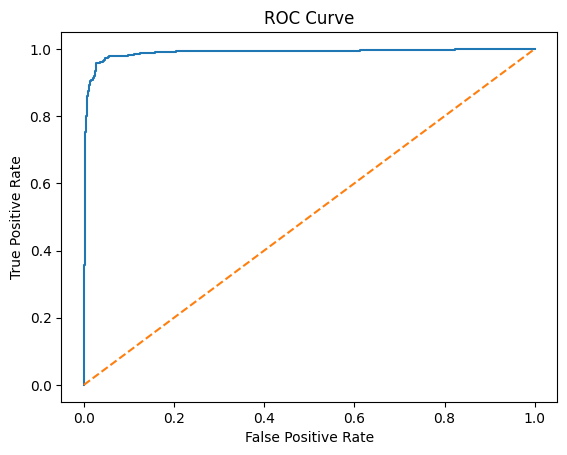

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# =========================
# 1. CREATE SAMPLE DATA (REMOVE THIS IF YOU HAVE REAL DATA)
# =========================
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

# =========================
# 2. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. TRAIN MODEL
# =========================
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

# =========================
# 4. PREDICTIONS
# =========================
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# =========================
# 5. METRICS
# =========================
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC AUC   :", roc_auc_score(y_test, y_prob))

# =========================
# 6. CONFUSION MATRIX
# =========================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =========================
# 7. CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 8. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.6277898


In [ ]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1:", f1_score(y_test, y_pred_opt))

Accuracy: 0.965
Precision: 0.9716024340770791
Recall: 0.958
F1: 0.9647532729103726


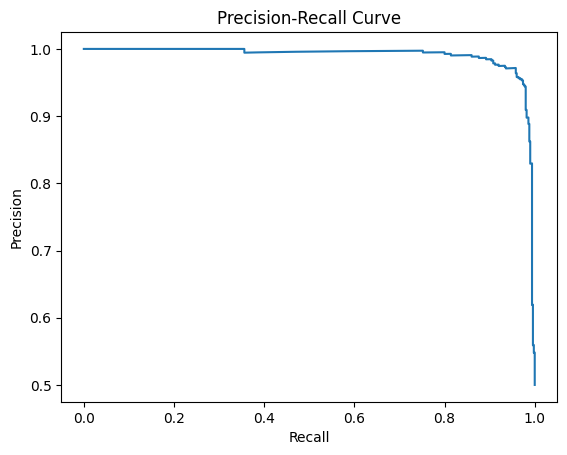

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
import pandas as pd

importance = pd.Series(xgb.feature_importances_)
importance.sort_values(ascending=False).head(15)

17    0.271086
10    0.139043
9     0.079291
13    0.057035
18    0.053270
7     0.049206
14    0.047060
6     0.045359
0     0.039838
3     0.039142
12    0.036685
5     0.030100
8     0.029305
2     0.028530
11    0.016561
dtype: float32

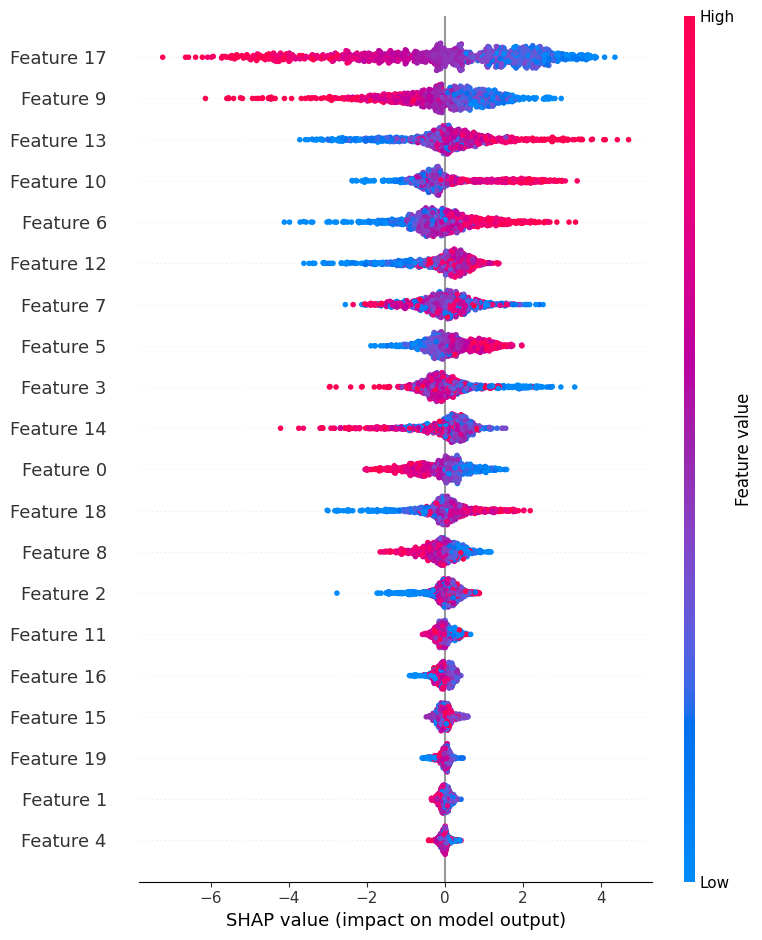

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
print("===== FINAL MODEL REPORT =====")
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 (default):", f1_score(y_test, y_pred))
print("F1 (optimized):", f1_score(y_test, y_pred_opt))
print("Best Threshold:", best_threshold)

===== FINAL MODEL REPORT =====
ROC AUC: 0.9892200000000001
F1 (default): 0.9619238476953907
F1 (optimized): 0.9647532729103726
Best Threshold: 0.6277898


METRICES EVALUTAION

In [8]:
print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print(
    "ROC AUC :",
    roc_auc_score(y_test,y_prob)
)

Accuracy : 0.962
Precision : 0.963855421686747
Recall : 0.96
F1 Score : 0.9619238476953907
ROC AUC : 0.9892200000000001


CONFUSION MATRIX

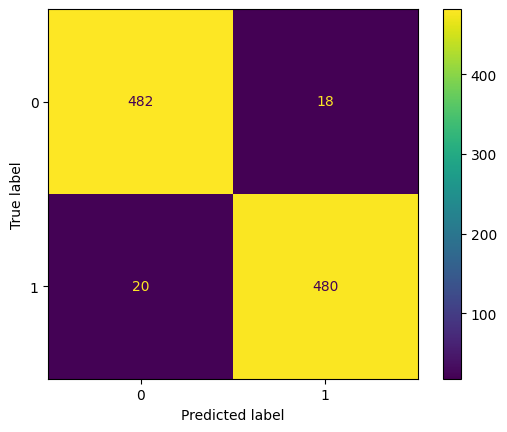

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig(
    "../reports/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

CLASSIFICATION REPORT

In [11]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       500
           1       0.96      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



CURVE-ROC

In [12]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.savefig(
    "../reports/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

c:\Users\SHUBHAM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 20 features, but RandomForestClassifier is expecting 13 features as input.

OPTIMAL THRESHOLD

In [13]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall
)

best_idx = np.argmax(
    f1_scores[:-1]
)

best_threshold = thresholds[
    best_idx
]

print(
    "Best Threshold:",
    best_threshold
)

Best Threshold: 0.6277898


NEW THRESHOLD

In [14]:
y_pred_opt = (
    y_prob >= best_threshold
).astype(int)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_opt
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_opt
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_opt
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        y_pred_opt
    )
)

Accuracy: 0.965
Precision: 0.9716024340770791
Recall: 0.958
F1: 0.9647532729103726


PRECISION RECALL CURVE

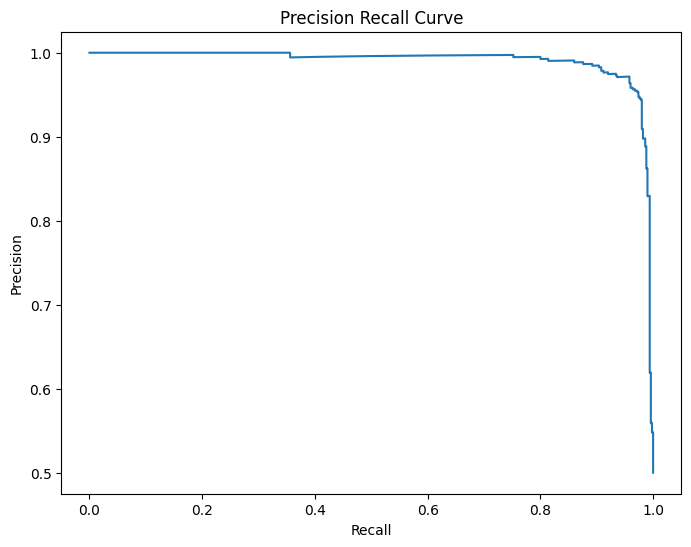

In [15]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve"
)

plt.savefig(
    "../reports/precision_recall_curve.png",
    bbox_inches="tight"
)

plt.show()

IMPORTANCE OF FEATURE

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

feature_importance.head(20)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

CHART FEATURE IMPORTANCE

In [21]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.savefig(
    "../reports/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

NameError: name 'feature_importance' is not defined

<Figure size 1000x600 with 0 Axes>

ANALYSIS-SHAP

In [18]:
import shap

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

SUMMARY PLOT- SHAP

In [2]:
import shap
import matplotlib.pyplot as plt

In [5]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

print("SHAP Summary Saved")

NameError: name 'shap_values' is not defined

FINAL REPORT

In [22]:
print("="*50)
print("FINAL MODEL REPORT")
print("="*50)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

print(
    "F1 Default:",
    f1_score(
        y_test,
        y_pred
    )
)

print(
    "F1 Optimized:",
    f1_score(
        y_test,
        y_pred_opt
    )
)

print(
    "Best Threshold:",
    best_threshold
)

FINAL MODEL REPORT
ROC AUC: 0.9892200000000001
F1 Default: 0.9619238476953907
F1 Optimized: 0.9647532729103726
Best Threshold: 0.6277898


In [6]:
import shap
import matplotlib.pyplot as plt
import joblib

In [7]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

In [8]:
explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

NameError: name 'X_test' is not defined

In [9]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight"
)

plt.close()

NameError: name 'shap_values' is not defined